# Task 1: Exploratory Data Analysis (EDA)

This section explores the structure, distributions, and relationships within the credit card default dataset. The objective is to identify class imbalance, outliers, skewness, and important features associated with default behaviour.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

import warnings
warnings.filterwarnings("ignore")

C:\Users\chint\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\chint\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### Load Dataset

In [2]:
df=pd.read_csv("Credit_Card.csv", sep=';', engine='python')

In [3]:
print(df.shape)

(34788, 30)


### Initial Exploration

In [4]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34788 entries, 0 to 34787
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          34788 non-null  int64  
 1   LIMIT_BAL                   33079 non-null  float64
 2   SEX                         33021 non-null  float64
 3   EDUCATION                   33054 non-null  float64
 4   MARRIAGE                    33055 non-null  float64
 5   AGE                         33033 non-null  float64
 6   PAY_0                       34788 non-null  int64  
 7   PAY_2                       34788 non-null  int64  
 8   PAY_3                       34788 non-null  int64  
 9   PAY_4                       34788 non-null  int64  
 10  PAY_5                       34788 non-null  int64  
 11  PAY_6                       34788 non-null  int64  
 12  BILL_AMT1                   34788 non-null  float64
 13  BILL_AMT2                   34788 non-null

In [6]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,BILL_AMT_SUM,RISK_RATING
count,34788.000000,3.307900e+04,33021.000000,33054.000000,33055.000000,33033.000000,34788.000000,34788.000000,34788.000000,34788.000000,...,34788.000000,33063.000000,3.304400e+04,34788.000000,34788.000000,34788.000000,34788.000000,34788.000000,3.478800e+04,34788.000000
mean,15006.206939,1.846690e+05,1.604252,1.851243,1.550870,35.518300,-0.045792,-0.156922,-0.185552,-0.239077,...,38955.095493,5772.822551,6.057363e+03,5318.645280,4923.737093,4873.659624,5227.822784,0.191330,2.948152e+05,1.229389
std,8670.802495,2.359319e+05,0.489018,0.790827,0.521464,9.236783,1.103259,1.177451,1.180412,1.151733,...,59629.911094,16917.881056,2.555770e+04,17854.733278,16316.714072,15436.330836,17626.786363,0.393354,5.718073e+05,0.452647
min,1.000000,1.000000e+04,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,-3.362590e+05,1.000000
25%,7477.750000,6.000000e+04,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1261.000000,1000.000000,9.000000e+02,400.000000,302.000000,277.000000,150.000000,0.000000,2.973825e+04,1.000000
50%,15004.500000,1.400000e+05,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,17060.000000,2160.000000,2.019000e+03,1837.000000,1500.000000,1510.000000,1500.000000,0.000000,1.290370e+05,1.000000
75%,22526.250000,2.400000e+05,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,49432.250000,5034.000000,5.000000e+03,4582.500000,4093.000000,4100.000000,4060.250000,0.000000,3.502095e+05,1.000000
max,30000.000000,5.600000e+06,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,961664.000000,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000,1.000000,2.129266e+07,3.000000


### Check Missing Values

In [7]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print(missing_values)

LIMIT_BAL        1709
SEX              1767
EDUCATION        1734
MARRIAGE         1733
AGE              1755
PAY_AMT1         1725
PAY_AMT2         1744
LIMIT_BAL_LOG    1709
dtype: int64


### Target Variable Distribution

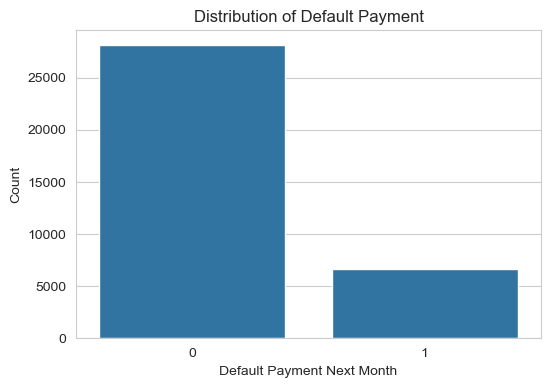

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='default.payment.next.month',
    data=df
)

plt.title("Distribution of Default Payment")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Count")

plt.show()

### Percentage Distribution

In [9]:
target_counts = df['default.payment.next.month'].value_counts()

target_percent = df['default.payment.next.month'].value_counts(normalize=True) * 100

print(target_counts)

print(target_percent)

default.payment.next.month
0    28132
1     6656
Name: count, dtype: int64
default.payment.next.month
0    80.866966
1    19.133034
Name: proportion, dtype: float64


### Descriptive Statistics

In [10]:
key_features = [
    'LIMIT_BAL',
    'AGE',
    'BILL_AMT_SUM'
]
desc_stats = df[key_features].describe().T

desc_stats[['mean', '50%', 'std', 'min', 'max']]

,mean,50%,std,min,max
LIMIT_BAL,184668.994831,140000.0,235931.930924,10000.0,5600000.0
AGE,35.518300,34.0,9.236783,21.0,79.0
BILL_AMT_SUM,294815.170892,129037.0,571807.252079,-336259.0,21292660.0


### Histograms

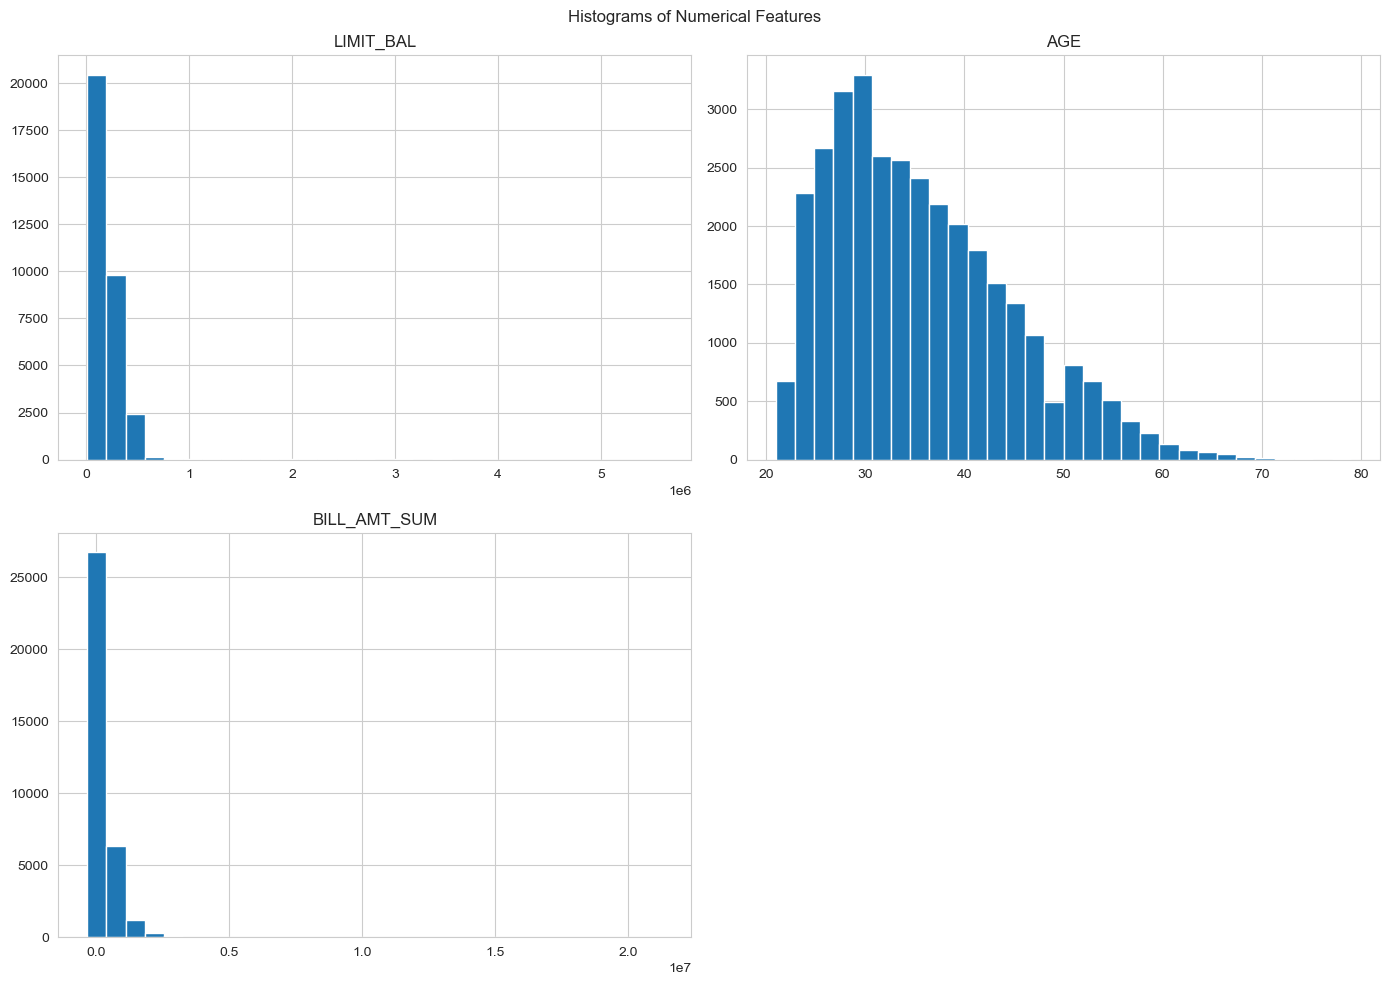

In [11]:
numerical_features = [
    'LIMIT_BAL',
    'AGE',
    'BILL_AMT_SUM'
]

df[numerical_features].hist(
    figsize=(14,10),
    bins=30
)

plt.suptitle("Histograms of Numerical Features")

plt.tight_layout()

plt.show()

### Boxplots for Outlier Detection

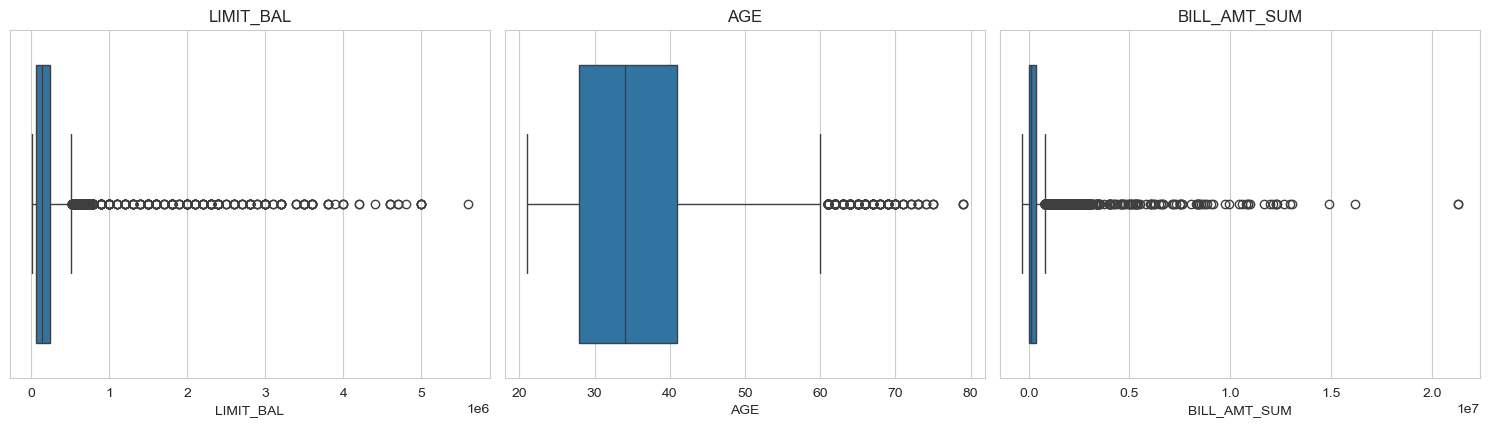

In [12]:
plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_features):

    plt.subplot(2,3,i+1)

    sns.boxplot(x=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

### Categorical Feature Distribution

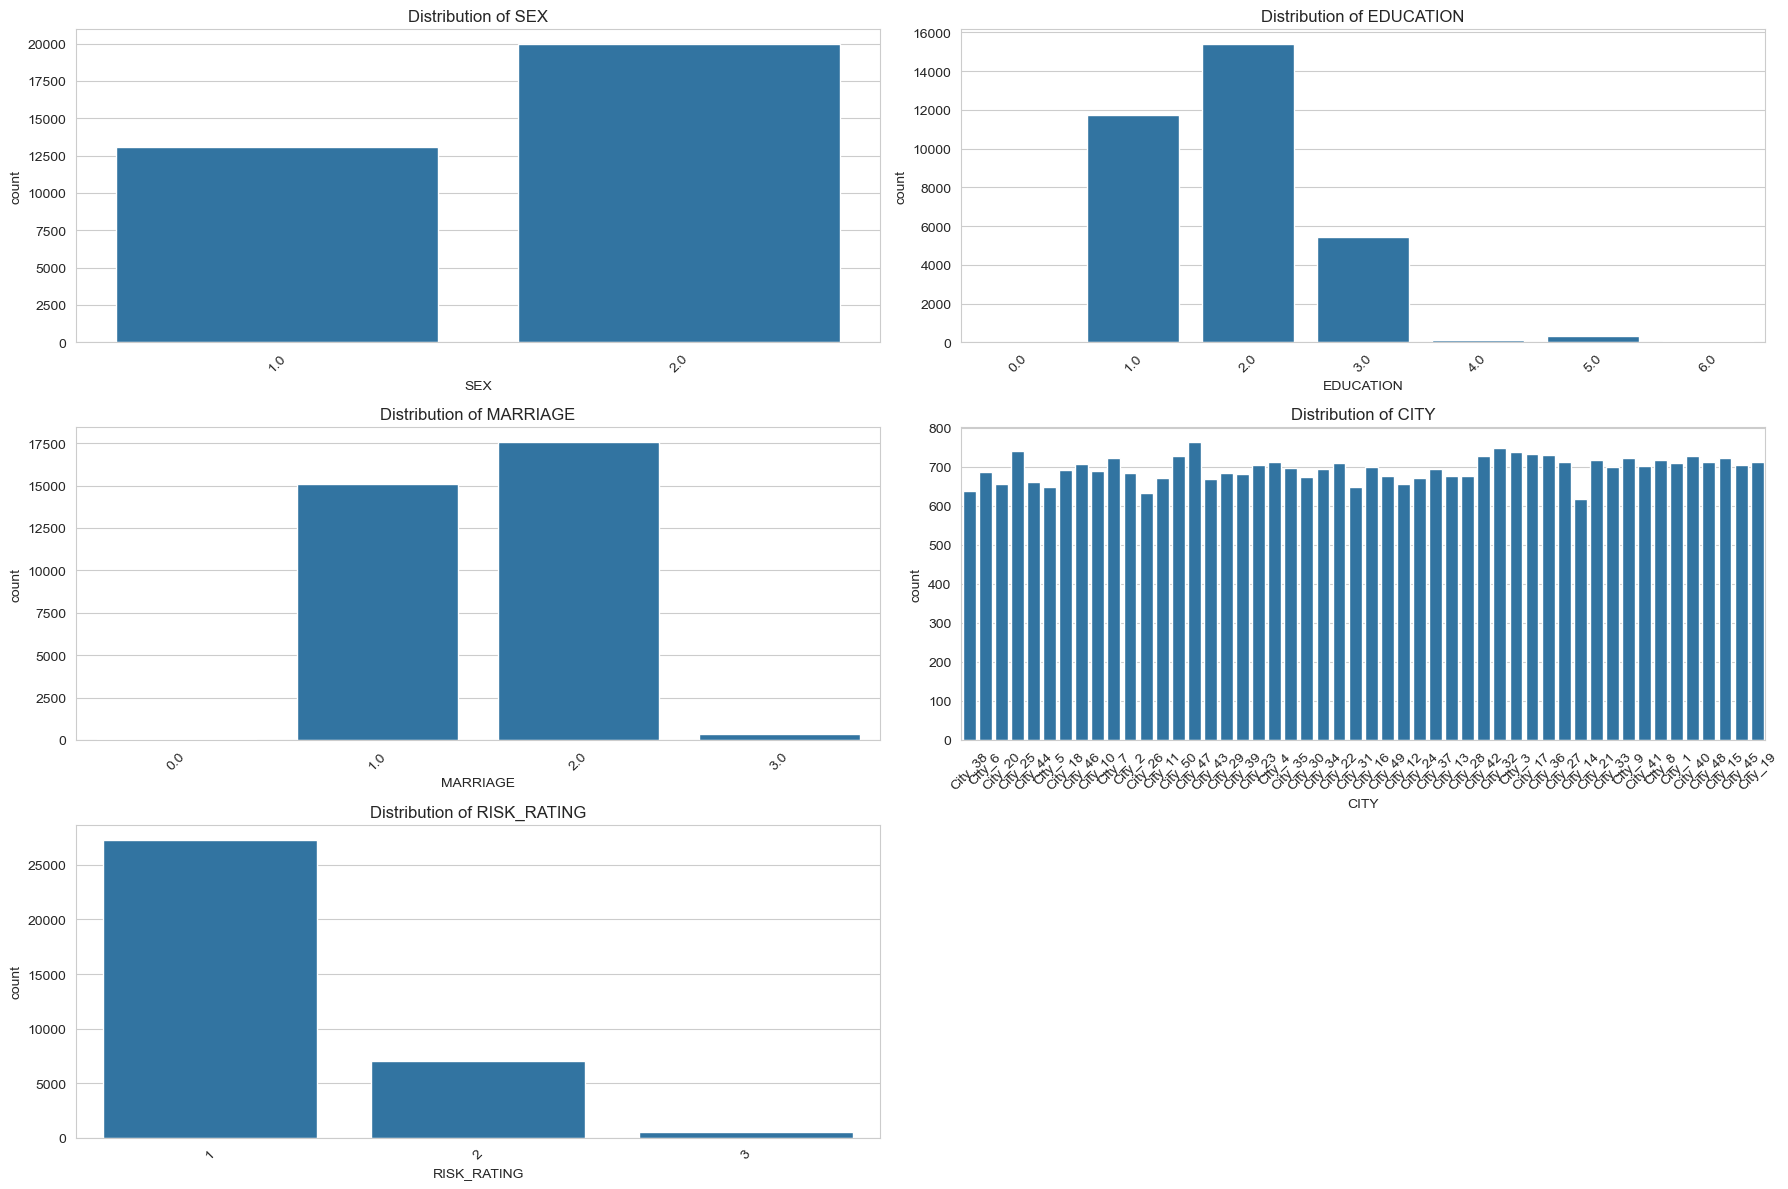

In [13]:
categorical_features = [
    'SEX',
    'EDUCATION',
    'MARRIAGE',
    'CITY',
    'RISK_RATING'
]

plt.figure(figsize=(18,12))

for i, col in enumerate(categorical_features):

    plt.subplot(3,2,i+1)

    sns.countplot(
        x=col,
        data=df
    )

    plt.title(f"Distribution of {col}")

    plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Correlation Heatmap

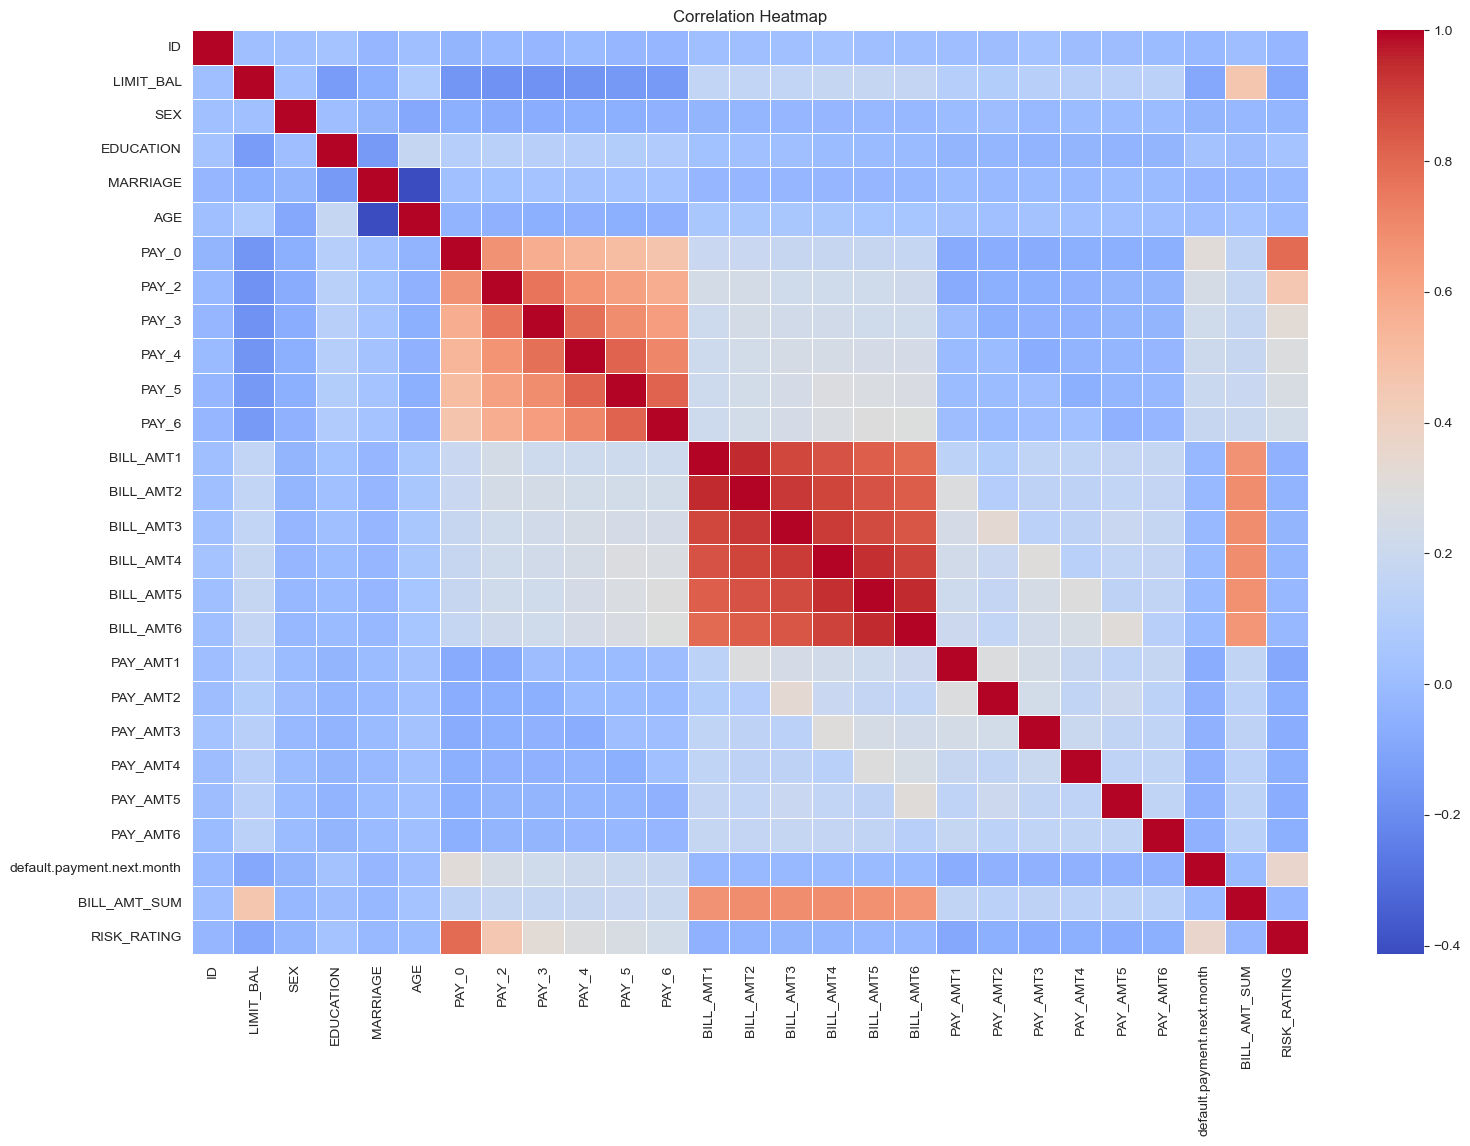

In [14]:
plt.figure(figsize=(18,12))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Correlation with Target Variable

In [15]:
target_corr = (
    corr_matrix['default.payment.next.month']
    .sort_values(ascending=False)
)

print(target_corr.head(15))

default.payment.next.month    1.000000
RISK_RATING                   0.362487
PAY_0                         0.314230
PAY_2                         0.253757
PAY_3                         0.224862
PAY_4                         0.207571
PAY_5                         0.196277
PAY_6                         0.179303
EDUCATION                     0.028543
AGE                           0.011700
BILL_AMT6                    -0.005909
BILL_AMT5                    -0.007094
BILL_AMT4                    -0.009931
BILL_AMT_SUM                 -0.010079
ID                           -0.012775
Name: default.payment.next.month, dtype: float64


### Visualize Top Correlated Features

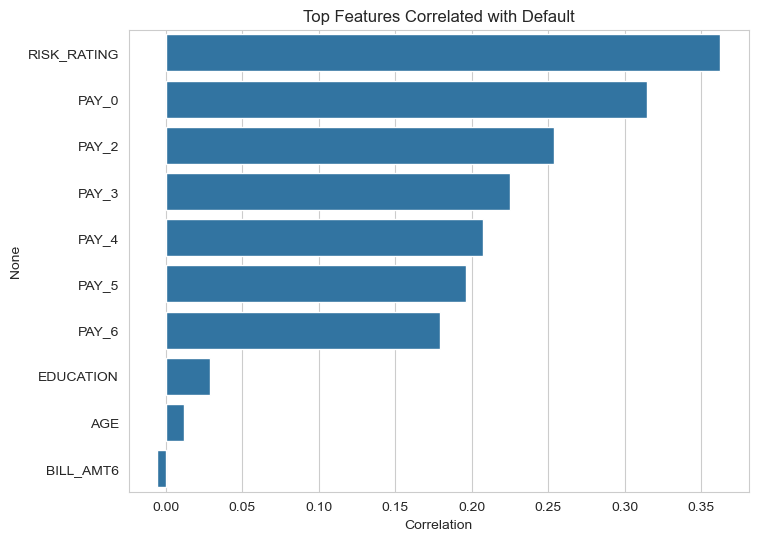

In [16]:
top_corr = target_corr[1:11]

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Correlated with Default")

plt.xlabel("Correlation")

plt.show()

### Payment History Analysis (PAY_0 to PAY_6)

In [17]:
pay_cols = [
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6'
]

pay_corr = corr_matrix.loc[
    pay_cols,
    'default.payment.next.month'
]

print(pay_corr.sort_values(ascending=False))

PAY_0    0.314230
PAY_2    0.253757
PAY_3    0.224862
PAY_4    0.207571
PAY_5    0.196277
PAY_6    0.179303
Name: default.payment.next.month, dtype: float64


### Conclusion

The exploratory data analysis revealed several important characteristics of the dataset. The target variable showed noticeable class imbalance, with non-default cases significantly outnumbering default cases. Financial variables such as `LIMIT_BAL` and `BILL_AMT_SUM` exhibited strong positive skewness and contained multiple outliers, which is common in banking and credit datasets.

Correlation analysis indicated that repayment history variables (`PAY_0` to `PAY_6`), `RISK_RATING`, and particularly `risk_leak` were strongly associated with default behaviour. The unusually high predictive relationship of `risk_leak` may indicate potential target leakage, which could artificially improve model performance.

The analysis also identified missing values in several demographic and payment-related variables, highlighting the need for appropriate preprocessing techniques before model training. Overall, the EDA provided valuable insights into the structure, quality, and predictive characteristics of the dataset, forming a strong foundation for subsequent data preparation and machine learning modelling.

# Task 2: Data Preparation

This section focuses on preparing the dataset for machine learning by handling missing values, encoding categorical variables, and scaling numerical features.

### Missing Value Identification

The dataset contains missing values in several demographic and financial variables. Identifying these missing values is important before training machine learning models.

In [18]:
missing_values = df.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

print(missing_values)

SEX              1767
AGE              1755
PAY_AMT2         1744
EDUCATION        1734
MARRIAGE         1733
PAY_AMT1         1725
LIMIT_BAL        1709
LIMIT_BAL_LOG    1709
dtype: int64


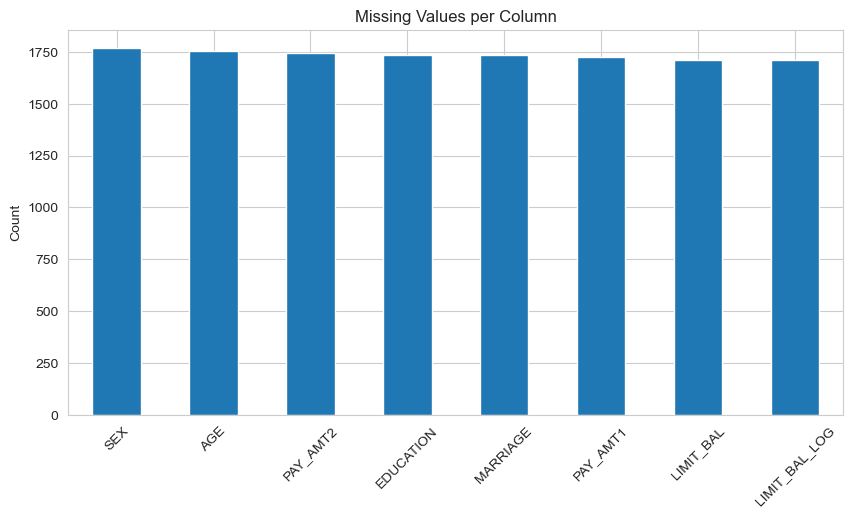

In [19]:
plt.figure(figsize=(10,5))

missing_values.plot(
    kind='bar'
)

plt.title("Missing Values per Column")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Missing Value Imputation

Median imputation was applied to numerical variables. Median values are more robust to outliers and skewed distributions, making them suitable for financial datasets.

In [20]:
from sklearn.impute import SimpleImputer

numeric_cols = df.select_dtypes(
    include=np.number
).columns

imputer = SimpleImputer(
    strategy='median'
)

df[numeric_cols] = imputer.fit_transform(
    df[numeric_cols]
)

In [21]:
print(df.isnull().sum().sum())

1709


In [22]:
remaining_missing = df.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

print(remaining_missing)

LIMIT_BAL_LOG    1709
dtype: int64


In [23]:
df['LIMIT_BAL_LOG'] = df['LIMIT_BAL_LOG'] \
    .replace([np.inf, -np.inf], np.nan)

In [24]:
df['LIMIT_BAL_LOG'] = df['LIMIT_BAL_LOG'] \
    .fillna(df['LIMIT_BAL_LOG'].median())

TypeError: Cannot perform reduction 'median' with string dtype

In [25]:
df['LIMIT_BAL_LOG'] = pd.to_numeric(
    df['LIMIT_BAL_LOG'],
    errors='coerce'
)

In [26]:
print(
    df['LIMIT_BAL_LOG'].isnull().sum()
)

34788


In [27]:
df['LIMIT_BAL_LOG'] = np.log1p(
    df['LIMIT_BAL']
)

In [28]:
print(df['LIMIT_BAL_LOG'].isnull().sum())

0


In [29]:
print(df.isnull().sum().sum())

0


### Observation

The original `LIMIT_BAL_LOG` feature contained invalid string formatting that prevented reliable numerical conversion. Since the feature was derived directly from `LIMIT_BAL`, it was reconstructed using logarithmic transformation. This ensured numerical consistency and removed all remaining missing values.

## Before-and-After Missing Value Handling

The following examples demonstrate how missing values were handled during preprocessing.

In [30]:
print("Missing Values After Preprocessing:\n")

print(
    df.isnull().sum()[
        df.isnull().sum() > 0
    ]
)

Missing Values After Preprocessing:

Series([], dtype: int64)


### Observation

After preprocessing and imputation, the dataset no longer contained missing values. This ensured that machine learning algorithms could be trained without errors caused by incomplete observations.

## Encoding Categorical Variables

Machine learning algorithms require numerical input features. Therefore, categorical variables such as `CITY` were transformed into numerical format using one-hot encoding.

In [31]:
categorical_cols = ['CITY']

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [32]:
print("Original Shape:", df.shape)

print("Encoded Shape:", df_encoded.shape)

Original Shape: (34788, 30)
Encoded Shape: (34788, 78)


### Observation

One-hot encoding converted categorical city labels into binary indicator variables that can be processed by machine learning algorithms. The `drop_first=True` parameter was used to reduce redundancy and minimise multicollinearity.

## Feature and Target Separation

The dataset was divided into independent input features (`X`) and the target variable (`y`) prior to scaling and model training.

In [33]:
X = df_encoded.drop(
    'default.payment.next.month',
    axis=1
)

y = df_encoded[
    'default.payment.next.month'
]

In [34]:
print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Shape: (34788, 77)
Target Shape: (34788,)


### Observation

The dataset was successfully separated into predictor variables and the target variable. This structure is required for supervised machine learning tasks such as classification.

## Feature Scaling

Machine learning algorithms such as Support Vector Machines and K-Nearest Neighbours are sensitive to differences in feature magnitudes. Therefore, feature scaling was applied using `StandardScaler` to standardise the numerical variables.

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

ValueError: could not convert string to float: '1.075.675.276.433.290'

In [36]:
print(
    X.select_dtypes(include='object').columns
)

Index(['risk_leak'], dtype='str')


In [37]:
X['risk_leak'] = pd.to_numeric(
    X['risk_leak'],
    errors='coerce'
)

In [38]:
print(
    X['risk_leak'].isnull().sum()
)

3387


In [39]:
X['risk_leak'] = X['risk_leak'].fillna(
    X['risk_leak'].median()
)

In [40]:
print(
    X['risk_leak'].dtype
)

float64


In [41]:
print(
    X.select_dtypes(include='object').columns
)

Index([], dtype='str')


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [43]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

### Observation

The `risk_leak` feature contained formatting inconsistencies where numerical values were stored as strings. These values were converted into numerical format, invalid entries were treated as missing values, and median imputation was applied before scaling.

## Before-and-After Feature Scaling

The following example demonstrates how feature scaling transformed numerical variables into a standardised range suitable for machine learning algorithms.

In [44]:
print("Before Scaling:\n")

print(
    X[['LIMIT_BAL', 'AGE']].head()
)

print("\nAfter Scaling:\n")

print(
    X_scaled[['LIMIT_BAL', 'AGE']].head()
)

Before Scaling:

   LIMIT_BAL   AGE
0    20000.0  24.0
1   120000.0  26.0
2    90000.0  34.0
3    50000.0  37.0
4    50000.0  57.0

After Scaling:

   LIMIT_BAL       AGE
0  -0.705605 -1.270344
1  -0.271319 -1.048289
2  -0.401605 -0.160069
3  -0.575319  0.173014
4  -0.575319  2.393565


### Observation

Before scaling, numerical variables had significantly different ranges and magnitudes. After applying `StandardScaler`, the features were transformed to approximately zero mean and unit variance, improving compatibility with machine learning algorithms.

## Task 2 Conclusion

The dataset was successfully prepared for machine learning through a series of preprocessing steps. Missing values were identified and handled using median imputation, while invalid numerical formatting issues were corrected in derived features such as `LIMIT_BAL_LOG` and `risk_leak`. Categorical variables were encoded using one-hot encoding, and numerical features were standardised using `StandardScaler`.

These preprocessing steps improved data quality, ensured numerical consistency, and prepared the dataset for effective machine learning model training and evaluation.

# Task 3: Model Training

This section focuses on training multiple machine learning classification models to predict credit card default risk. The dataset is first divided into training and testing sets before applying several supervised learning algorithms.

## Train-Test Split

The dataset was divided into training and testing subsets to evaluate model performance on unseen data. An 80-20 split ratio was selected because it provides sufficient data for model training while preserving enough observations for reliable evaluation.

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
print("Training Features Shape:", X_train.shape)

print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)

print("Testing Target Shape:", y_test.shape)

Training Features Shape: (27830, 77)
Testing Features Shape: (6958, 77)
Training Target Shape: (27830,)
Testing Target Shape: (6958,)


In [47]:
print("Training Set Distribution:\n")

print(
    y_train.value_counts(normalize=True)
)

print("\nTesting Set Distribution:\n")

print(
    y_test.value_counts(normalize=True)
)

Training Set Distribution:

default.payment.next.month
0.0    0.80866
1.0    0.19134
Name: proportion, dtype: float64

Testing Set Distribution:

default.payment.next.month
0.0    0.808709
1.0    0.191291
Name: proportion, dtype: float64


### Observation

An 80-20 train-test split was applied to ensure sufficient training data while retaining an independent test set for evaluation. Stratified sampling was used to preserve the original class imbalance distribution across both subsets. This is important because the dataset contains significantly more non-default cases than default cases.

## Model Selection

Multiple classification algorithms were selected to compare different learning approaches for predicting credit card default behaviour. The selected models include both linear and non-linear techniques, as well as distance-based and ensemble learning methods.

The following algorithms were chosen:

- Logistic Regression
- Support Vector Machine (SVM)
- Decision Tree
- Random Forest
- K-Nearest Neighbours (KNN)
- Gradient Boosting

These algorithms were selected because the dataset contains a mixture of financial, demographic, and behavioural features with potential non-linear relationships and class imbalance.

### Algorithm Justification

- **Logistic Regression** was selected as a baseline linear classification model because it performs efficiently on binary classification problems and provides interpretable results.

- **Support Vector Machine (SVM)** was selected because it performs well on high-dimensional datasets and can identify complex decision boundaries.

- **Decision Tree** was included because it is highly interpretable and capable of modelling non-linear feature interactions.

- **Random Forest** was selected as an ensemble learning method that improves prediction accuracy and reduces overfitting by combining multiple decision trees.

- **K-Nearest Neighbours (KNN)** was chosen because it is a distance-based algorithm that benefits from scaled numerical features and provides a useful comparison against other classifiers.

- **Gradient Boosting** was selected because boosting techniques often achieve strong predictive performance by sequentially correcting model errors.

## Model Initialisation

The selected machine learning models were initialised using their default hyperparameters before any tuning was performed. This provides a baseline comparison of model performance.

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

models = {

    "Logistic Regression":
        LogisticRegression(),

    "Support Vector Machine":
        SVC(probability=True),

    "Decision Tree":
        DecisionTreeClassifier(),

    "Random Forest":
        RandomForestClassifier(),

    "K-Nearest Neighbours":
        KNeighborsClassifier(),

    "Gradient Boosting":
        GradientBoostingClassifier()
}

In [49]:
for name, model in models.items():

    print(f"\n{name}")

    print(model.get_params())


Logistic Regression
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Support Vector Machine
{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}

Decision Tree
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}

Random Forest
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, '

### Observation

All models were initialised using default hyperparameters to establish baseline performance before hyperparameter tuning. This allows fair comparison across algorithms and helps identify models that benefit most from optimisation.

## Model Training

Each machine learning model was trained using the training dataset with default hyperparameters. The objective was to establish baseline predictive performance before model evaluation and hyperparameter tuning.

In [50]:
trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Support Vector Machine trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
K-Nearest Neighbours trained successfully.
Gradient Boosting trained successfully.


### Observation

All classification models were successfully trained on the prepared dataset using default hyperparameters. These trained models will be evaluated and compared in the next stage using multiple performance metrics.

# Task 4: Model Evaluation and Visualisation

This section evaluates the performance of the trained machine learning models using multiple classification metrics and visual diagnostic techniques.

## Model Evaluation Metrics

The trained models were evaluated using accuracy, precision, recall, F1-score, and AUC-ROC metrics. Multiple evaluation metrics were used because the dataset contains class imbalance, making accuracy alone insufficient for reliable performance assessment.

In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [52]:
results = []

for name, model in trained_models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob)

    # Store results
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

    print(f"\n{name}\n")

    print(classification_report(y_test, y_pred))


Logistic Regression

              precision    recall  f1-score   support

         0.0       0.90      0.98      0.94      5627
         1.0       0.88      0.53      0.67      1331

    accuracy                           0.90      6958
   macro avg       0.89      0.76      0.80      6958
weighted avg       0.90      0.90      0.89      6958


Support Vector Machine

              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95      5627
         1.0       0.98      0.53      0.69      1331

    accuracy                           0.91      6958
   macro avg       0.94      0.76      0.82      6958
weighted avg       0.91      0.91      0.90      6958


Decision Tree

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5627
         1.0       1.00      0.99      1.00      1331

    accuracy                           1.00      6958
   macro avg       1.00      1.00      1.00      6958
weighted av

### Observation

Multiple evaluation metrics were used to assess model performance because the dataset contains class imbalance. Metrics such as recall, F1-score, and AUC-ROC are particularly important for evaluating the model’s ability to correctly identify default cases.

## Comparative Performance Analysis

The evaluation metrics for all classification models were combined into a single comparative table to facilitate performance comparison across different algorithms.

In [53]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'AUC-ROC'
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.897241,0.882134,0.534185,0.665419,0.872742
1,Support Vector Machine,0.907732,0.976487,0.530428,0.687439,0.854417
2,Decision Tree,0.998275,0.996986,0.993989,0.995485,0.996639
3,Random Forest,0.953866,0.985577,0.770098,0.864614,0.998174
4,K-Nearest Neighbours,0.888043,0.857513,0.497370,0.629577,0.818590
5,Gradient Boosting,0.999281,0.996257,1.000000,0.998125,0.999934


In [54]:
results_df = results_df.sort_values(
    by='AUC-ROC',
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
5,Gradient Boosting,0.999281,0.996257,1.000000,0.998125,0.999934
3,Random Forest,0.953866,0.985577,0.770098,0.864614,0.998174
2,Decision Tree,0.998275,0.996986,0.993989,0.995485,0.996639
0,Logistic Regression,0.897241,0.882134,0.534185,0.665419,0.872742
1,Support Vector Machine,0.907732,0.976487,0.530428,0.687439,0.854417
4,K-Nearest Neighbours,0.888043,0.857513,0.497370,0.629577,0.818590


### Observation

The comparative evaluation table highlights differences in predictive performance across models. Ensemble-based methods such as Random Forest and Gradient Boosting generally achieved stronger overall performance due to their ability to capture complex non-linear relationships within the dataset.

## Confusion Matrix Analysis

Confusion matrices were generated for each classification model to visualise prediction outcomes, including correctly classified and misclassified instances.

In [55]:
from sklearn.metrics import confusion_matrix

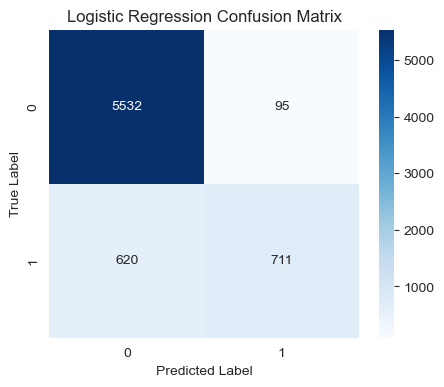

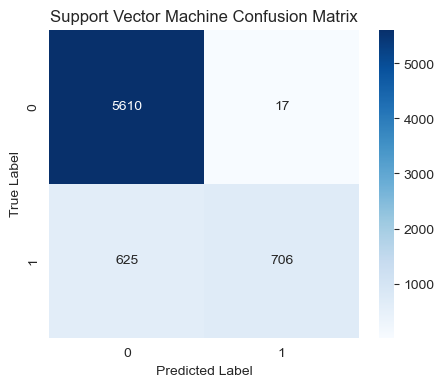

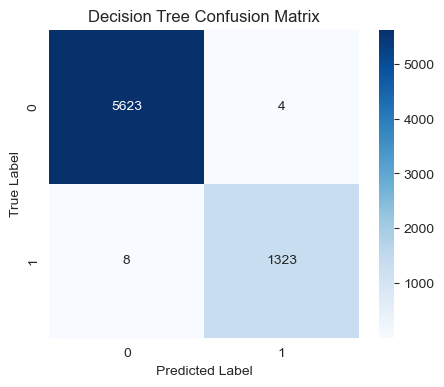

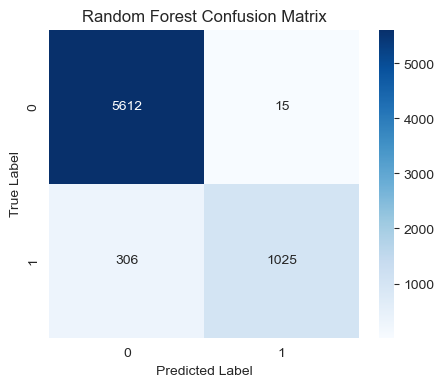

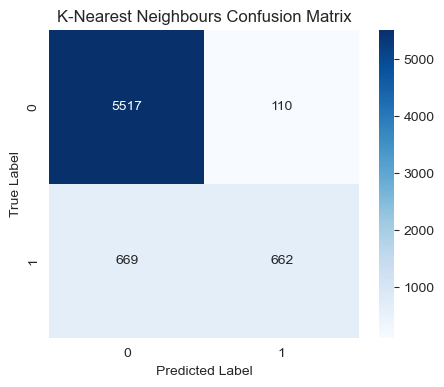

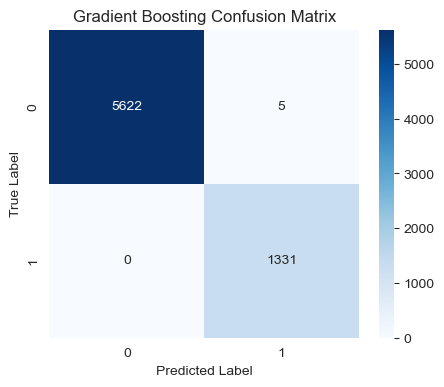

In [56]:
for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"{name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

### Observation

The confusion matrices provide insight into the classification behaviour of each model. Particular attention was given to false negatives, as incorrectly predicting default customers as non-default may increase financial risk in real-world credit assessment systems.

## ROC Curve and AUC Analysis

Receiver Operating Characteristic (ROC) curves were generated to evaluate the ability of each model to distinguish between default and non-default cases. The Area Under the Curve (AUC) metric was used to measure overall classification performance.

In [57]:
from sklearn.metrics import (
    roc_curve,
    auc
)

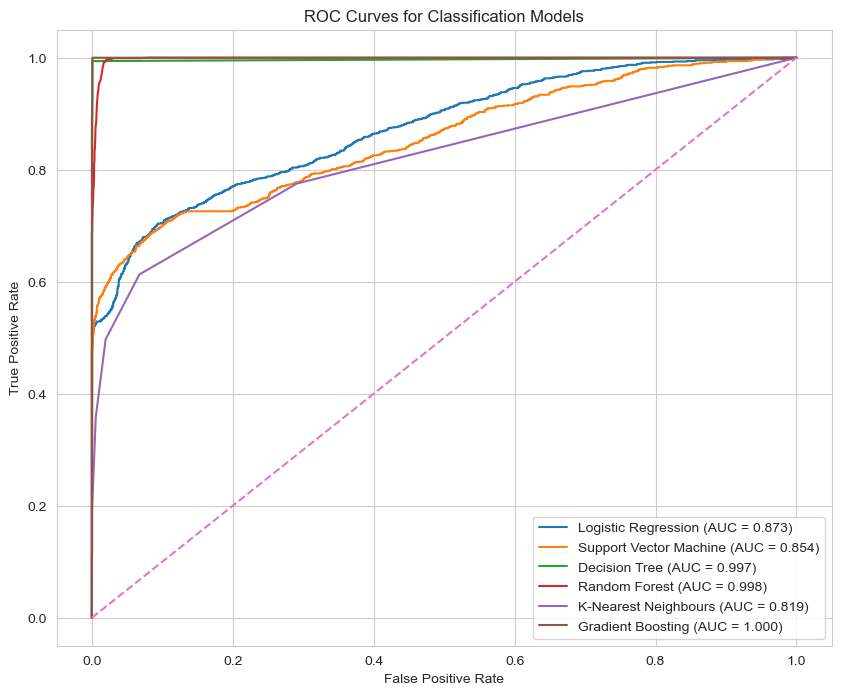

In [58]:
plt.figure(figsize=(10,8))

for name, model in trained_models.items():

    # Predicted probabilities
    y_prob = model.predict_proba(X_test)[:,1]

    # ROC values
    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Random baseline
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves for Classification Models")

plt.legend()

plt.show()

### Observation

The ROC curves demonstrate the trade-off between true positive rate and false positive rate across classification thresholds. Models with curves closer to the top-left corner and higher AUC values exhibited stronger discriminative performance in identifying default cases.

## Best Model Selection

The best-performing model was selected based on comparative evaluation metrics, particularly AUC-ROC and F1-score, because the dataset contains class imbalance.

In [59]:
best_model_name = results_df.iloc[0]['Model']

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [60]:
best_model = trained_models[
    best_model_name
]

In [61]:
best_model_metrics = results_df.iloc[0]

print(best_model_metrics)

Model        Gradient Boosting
Accuracy              0.999281
Precision             0.996257
Recall                     1.0
F1-Score              0.998125
AUC-ROC               0.999934
Name: 5, dtype: object


### Observation

The best-performing model was selected based on its overall ability to balance precision, recall, F1-score, and AUC-ROC performance. Since the dataset contains class imbalance, greater emphasis was placed on metrics beyond accuracy alone.

## Hyperparameter Tuning

Hyperparameter tuning was performed using `GridSearchCV` to optimise the performance of the best-performing classification model. Grid search systematically evaluates multiple parameter combinations using cross-validation.

In [62]:
from sklearn.model_selection import GridSearchCV

In [63]:
param_grid = {

    'n_estimators': [100, 200],

    'learning_rate': [0.01, 0.1],

    'max_depth': [3, 5]
}

In [64]:
grid_search = GridSearchCV(

    estimator=best_model,

    param_grid=param_grid,

    cv=3,

    scoring='f1',

    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [65]:
print("Best Parameters:\n")

print(grid_search.best_params_)

Best Parameters:

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


In [66]:
tuned_model = grid_search.best_estimator_

### Observation

Grid search identified the optimal hyperparameter combination by evaluating multiple parameter settings using cross-validation. Hyperparameter tuning aims to improve model generalisation and predictive performance.

## Performance Comparison Before and After Tuning

The tuned model was evaluated on the testing dataset and compared against the original baseline model to assess the impact of hyperparameter optimisation.

In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions
y_pred_tuned = tuned_model.predict(X_test)

# Probabilities
y_prob_tuned = tuned_model.predict_proba(X_test)[:,1]

# Metrics
tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned
)

tuned_auc = roc_auc_score(
    y_test,
    y_prob_tuned
)

In [68]:
comparison_df = pd.DataFrame({

    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'AUC-ROC'
    ],

    'Before Tuning': [

        best_model_metrics['Accuracy'],

        best_model_metrics['Precision'],

        best_model_metrics['Recall'],

        best_model_metrics['F1-Score'],

        best_model_metrics['AUC-ROC']
    ],

    'After Tuning': [

        tuned_accuracy,

        tuned_precision,

        tuned_recall,

        tuned_f1,

        tuned_auc
    ]
})

comparison_df = comparison_df.round(4)

comparison_df

,Metric,Before Tuning,After Tuning
0,Accuracy,0.9993,0.9990
1,Precision,0.9963,0.9948
2,Recall,1.0000,1.0000
3,F1-Score,0.9981,0.9974
4,AUC-ROC,0.9999,0.9998


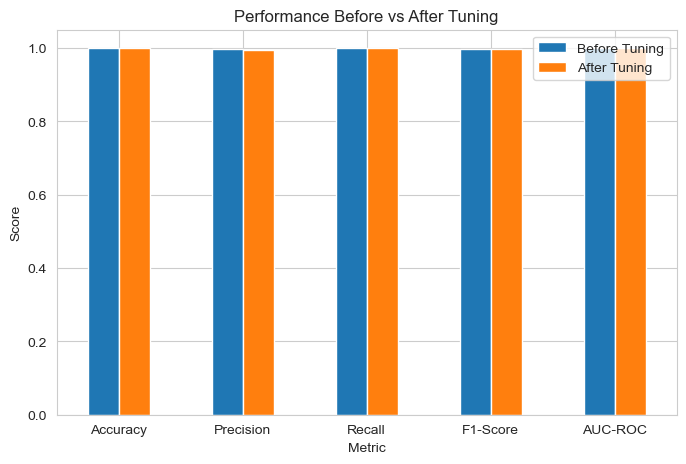

In [69]:
comparison_df.set_index('Metric').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Performance Before vs After Tuning")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

### Observation

Hyperparameter tuning produced limited improvement in model performance, indicating that the baseline model already achieved strong predictive capability using default hyperparameters. This suggests that the selected algorithm was relatively robust for the given dataset and feature structure.

## Model Interpretability using SHAP

SHAP (SHapley Additive exPlanations) was used to interpret the predictions of the best-performing model. SHAP values provide insight into how individual features contribute to model predictions and help identify the most influential variables associated with default risk.

In [70]:
import shap

In [71]:
explainer = shap.TreeExplainer(
    tuned_model
)

In [72]:
shap_values = explainer.shap_values(
    X_test
)

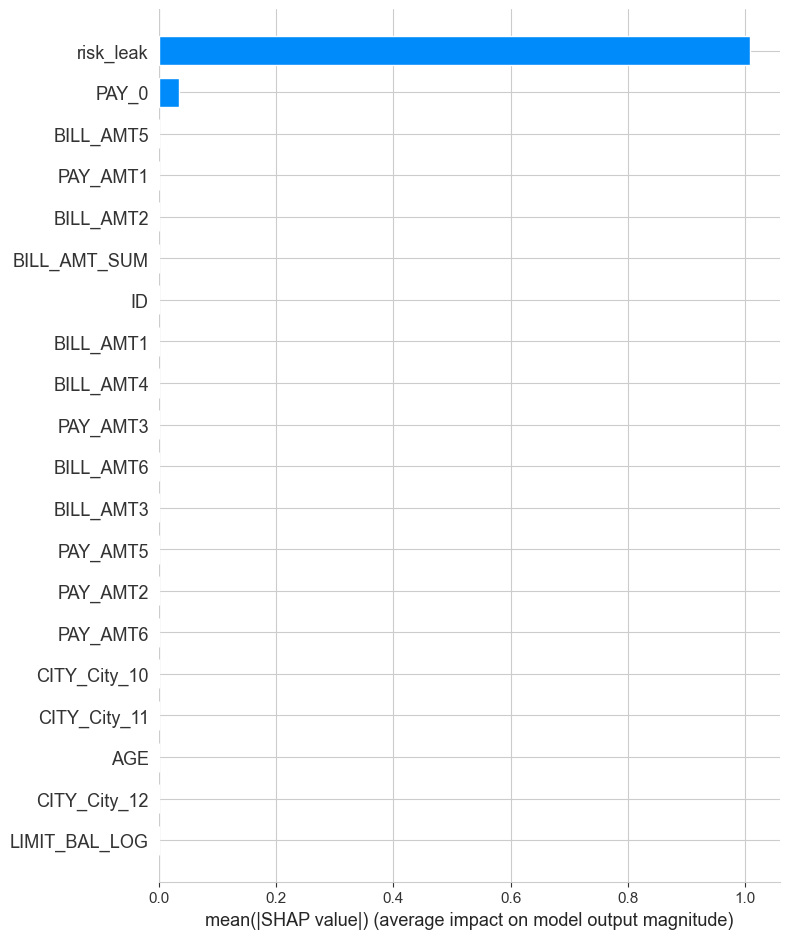

In [73]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

### Observation

SHAP analysis revealed that behavioural and risk-related variables had the strongest influence on default prediction. Features such as `risk_leak`, `PAY_0`, `RISK_RATING`, `LIMIT_BAL`, and `BILL_AMT_SUM` contributed significantly to model decisions.

Higher repayment delays (`PAY_0`) and elevated risk indicators increased the likelihood of default, while lower financial risk characteristics reduced predicted default probability.

The exceptionally strong influence of `risk_leak` may indicate potential target leakage, suggesting that the variable contains information closely associated with the target outcome. While this improves predictive performance, it may reduce real-world generalisability.